# 경상도 분석

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

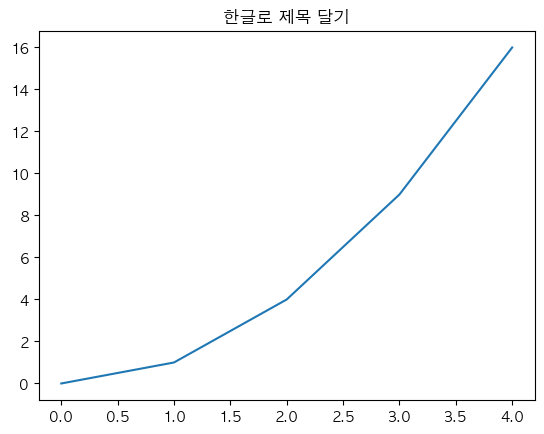

In [131]:
# 맥 한글 설정 아래 블로그서 가져옴
# https://wannabe00.tistory.com/entry/Mac%EC%97%90%EC%84%9C-Matplotlib-%EC%82%AC%EC%9A%A9-%EC%8B%9C-%ED%95%9C%EA%B8%80-%EA%B9%A8%EC%A7%90-%ED%95%B4%EA%B2%B0

from matplotlib import rc

rc('font', family='AppleGothic') 			## 이 두 줄을 
plt.rcParams['axes.unicode_minus'] = False  ## 추가해줍니다. 

plt.figure()
plt.plot([i**2 for i in range(5)])
plt.title('한글로 제목 달기')
plt.show()          

In [132]:
# 날씨 데이터 확인
weather_df = pd.read_csv('./data/weather_data_201501_202412.csv', encoding='cp949')
weather_df2 = pd.read_csv('./data/weather_data_201501_202412.csv', encoding='cp949')

# '울산' in weather_df['지점명'].unique()

# weather_df.info()

# 결측치 각각 얼마나 있는지 확인 / 최심적설은 0으로 채우고 나머지는 각 월의 평균으로 넣을 예정
for i in weather_df.columns:
    print(f"{i:<20} | null value count is : {weather_df[i].isnull().sum()}")

print()
# print(weather_df['지점명'].unique())

# 이상치 확인 / 평균상대습도 99%는 가능한 수치임을 확인
display(weather_df.describe())

display(weather_df.head())

지점                   | null value count is : 0
지점명                  | null value count is : 0
일시                   | null value count is : 0
평균기온(°C)             | null value count is : 8
평균현지기압(hPa)          | null value count is : 8
평균해면기압(hPa)          | null value count is : 8
평균수증기압(hPa)          | null value count is : 10
평균상대습도(%)            | null value count is : 10
월합강수량(00~24h만)(mm)   | null value count is : 12
평균풍속(m/s)            | null value count is : 20
일조율(%)               | null value count is : 4
최심적설(cm)             | null value count is : 10827
평균지면온도(°C)           | null value count is : 23



,지점,평균기온(°C),평균현지기압(hPa),평균해면기압(hPa),평균수증기압(hPa),평균상대습도(%),월합강수량(00~24h만)(mm),평균풍속(m/s),일조율(%),최심적설(cm),평균지면온도(°C)
count,11423.000000,11415.000000,11415.000000,11415.000000,11413.000000,11413.000000,11411.000000,11403.000000,11419.000000,596.000000,11400.000000
mean,197.425282,13.478563,1004.005283,1016.453850,12.948138,69.643564,110.337709,1.958493,51.930762,7.075000,15.643395
std,64.245690,9.132526,15.979862,6.703078,8.173073,10.922087,115.812094,0.988665,11.991296,13.866678,10.342618
min,90.000000,-8.500000,920.500000,1003.800000,2.100000,32.000000,0.000000,0.500000,0.400000,0.000000,-6.200000
25%,136.000000,5.700000,998.800000,1009.300000,5.900000,62.000000,31.600000,1.300000,44.110000,1.200000,6.300000
50%,202.000000,14.000000,1006.500000,1017.500000,10.700000,71.000000,74.200000,1.700000,53.250000,3.400000,16.200000
75%,258.000000,21.800000,1014.400000,1022.700000,19.500000,78.000000,148.200000,2.300000,60.885000,6.700000,25.200000
max,296.000000,29.900000,1026.500000,1028.400000,34.800000,99.000000,947.400000,10.000000,104.490000,162.800000,36.600000


,지점,지점명,일시,평균기온(°C),평균현지기압(hPa),평균해면기압(hPa),평균수증기압(hPa),평균상대습도(%),월합강수량(00~24h만)(mm),평균풍속(m/s),일조율(%),최심적설(cm),평균지면온도(°C)
0,90,속초,2015-01,1.8,1019.8,1022.1,3.7,52.0,8.7,2.2,60.79,3.0,1.2
1,90,속초,2015-02,2.4,1018.0,1020.2,4.4,59.0,32.1,2.5,62.81,8.7,2.3
2,90,속초,2015-03,6.6,1017.0,1019.2,5.2,52.0,8.0,2.5,74.49,NaN,8.5
3,90,속초,2015-04,11.1,1014.0,1016.2,8.1,69.0,74.2,2.5,46.87,NaN,12.8
4,90,속초,2015-05,17.8,1005.8,1007.9,11.5,61.0,9.2,2.4,67.60,NaN,23.7


In [140]:
# 날씨 데이터 정제

# 최심적설 0 채우기
weather_df['최심적설(cm)'] = weather_df['최심적설(cm)'].fillna(0)

# 날씨 일자 datetime 형식으로 변환 월별 데이터기 때문에 '일'로 01 붙음
weather_df['일시'] = pd.to_datetime(weather_df['일시'])
weather_df2['일시'] = pd.to_datetime(weather_df2['일시'])
# print(weather_df['일시'].dtype)


# 기타 결측치 '해당 월'의 평균으로 채우기

# 내 방법
month_list = list(range(6,7))

for column in weather_df.iloc[:,3:].columns:
    nan_df = weather_df[weather_df[column].isna()].copy()
    not_nan_df = weather_df[weather_df[column].notna()].copy()
    
    # 해당 column의 nan, 날짜, 지역 확인
    print(nan_df[column], nan_df.loc[:,'지점명':'일시'])   # 확인용
    print()                                # 확인용

    for i in month_list:
        month_check1 = (not_nan_df['일시'].dt.month == i)
        month_check2 = (nan_df['일시'].dt.month == i)
        
        # 결측치 채우기 전 해당월 nan 확인
        print(nan_df.loc[month_check2, column], nan_df.loc[month_check2, '지점명':'일시'])   # 확인용

        month_avg = not_nan_df.loc[month_check1, column].mean()
        nan_df.loc[month_check2, column] = month_avg

        # 결측치 채운 후 채운값 확인
        print(nan_df.loc[month_check2, column], nan_df.loc[month_check2, '지점명':'일시'])   # 확인용
        print()

        # 해당 월 nan값 weather_df에 업로드
        weather_df.update(nan_df.loc[month_check2, column])
        # weather_df = weather_df.combine_first(nan_df.loc[month_check2, column])
    

# 제미나이 방법 (1)
# for column in weather_df.iloc[:, 3:].columns:
#     # 1. 원본의 결측치 위치를 기억
#     nan_mask = weather_df[column].isna()
    
#     for i in range(1, 13): # 1월~12월 전체로 확대
#         # 해당 월이면서 결측치인 행들
#         month_mask = (weather_df['일시'].dt.month == i)
        
#         # 해당 월의 정상 값들로부터 평균 계산
#         month_avg = weather_df.loc[month_mask & ~nan_mask, column].mean()
        
#         # 원본의 해당 위치에 바로 대입 (가장 깔끔함)
#         weather_df.loc[month_mask & nan_mask, column] = month_avg


# 제미나이 방법 (2)
# '월' 정보를 기준으로 그룹화한 뒤, 각 그룹의 평균(mean)으로 결측치(fillna)를 채움
# for column in weather_df.iloc[:, 3:].columns:
#     weather_df[column] = weather_df[column].fillna(
#         weather_df.groupby(weather_df['일시'].dt.month)[column].transform('mean')
#     )

# 마지막으로 월별 데이터가 아예 없는 경우 mean = nan 될 수 있기 때문에 전체 평균으로 fillna 해주기
weather_df[column] = weather_df[column].fillna(weather_df[column].mean)

# nan 값들이 채워졌는지 확인
for i in weather_df.columns:
    print(f"{i:<20} | null value count is : {weather_df[i].isnull().sum()}")

print()
print(weather_df.isnull().sum())


# weather_df.loc[weather_df['일시'].dt.month==6, '평균기온(°C)'].mean() # 평균 제대로 들어갔는지 확인용




4641    NaN
4651    NaN
4834    NaN
7131    NaN
8669    NaN
11399   NaN
Name: 평균기온(°C), dtype: float64            지점명         일시
4641        고창 2023-07-01
4651        고창 2024-05-01
4834   진도(첨찰산) 2019-08-01
7131        세종 2019-05-01
8669       강진군 2017-07-01
11399      북부산 2023-01-01

Series([], Name: 평균기온(°C), dtype: float64) Empty DataFrame
Columns: [지점명, 일시]
Index: []
Series([], Name: 평균기온(°C), dtype: float64) Empty DataFrame
Columns: [지점명, 일시]
Index: []

4641    NaN
4651    NaN
4834    NaN
7131    NaN
8669    NaN
10854   NaN
11399   NaN
Name: 평균현지기압(hPa), dtype: float64            지점명         일시
4641        고창 2023-07-01
4651        고창 2024-05-01
4834   진도(첨찰산) 2019-08-01
7131        세종 2019-05-01
8669       강진군 2017-07-01
10854       합천 2019-08-01
11399      북부산 2023-01-01

Series([], Name: 평균현지기압(hPa), dtype: float64) Empty DataFrame
Columns: [지점명, 일시]
Index: []
Series([], Name: 평균현지기압(hPa), dtype: float64) Empty DataFrame
Columns: [지점명, 일시]
Index: []

4641    NaN
4651    NaN
483

In [134]:
region_list = weather_df['지점명'].unique()

In [135]:
# 내 코드 검증 방식 ('해당월'로만 비교)
# 예: '서울' 지역의 데이터 중 원래 결측치였을 법한 구간 확인
sample_region = '진도군'
sample_month = 6
print('서울' in region_list)

region_month_condition = (weather_df['지점명'] == sample_region) & (weather_df['일시'].dt.month == sample_month)
print(weather_df[region_month_condition])

True
       지점  지점명         일시  평균기온(°C)  평균현지기압(hPa)  평균해면기압(hPa)  평균수증기압(hPa)  \
9484  268  진도군 2015-06-01   20.6000       1006.4       1007.0         21.1   
9496  268  진도군 2016-06-01   21.4000       1007.0       1007.6         22.5   
9508  268  진도군 2017-06-01   21.0000       1007.9       1008.5         19.1   
9520  268  진도군 2018-06-01   21.4000       1007.0       1007.6         20.6   
9532  268  진도군 2019-06-01   20.4000       1006.3       1006.9         18.9   
9544  268  진도군 2020-06-01   21.8000       1005.6       1006.2         21.8   
9556  268  진도군 2021-06-01   21.9551       1006.3       1007.7         19.9   
9568  268  진도군 2022-06-01   22.0000       1005.9       1007.0         22.2   
9580  268  진도군 2023-06-01   21.6000       1005.4       1006.5         21.2   
9592  268  진도군 2024-06-01   21.6000       1006.9       1008.1         20.9   

      평균상대습도(%)  월합강수량(00~24h만)(mm)  평균풍속(m/s)  일조율(%)  최심적설(cm) 평균지면온도(°C)  
9484       88.0               120.7        2.0   32.36    

In [141]:
# 기타 결측치 '해당지역'의 '해당 월' 평균으로 채우기 

month_list = list(range(1,13))
region_list = weather_df['지점명'].unique()
# print(region_list)

for column in weather_df2.iloc[:,3:].columns:
    # 1. 원본 결측치 위치를 기억
    nan_mask = weather_df2[column].isna()
    # nan_mask_F_count = weather_df[column].isna().sum().item()
    # nan_mask_F_count
    

    # 2. 월 결측치 위치를 기억
    for m in month_list:
        month_mask = (weather_df2['일시'].dt.month == m)

        # 3. 해당 지역 위치 기억
        for region in region_list:
            region_mask = weather_df2['지점명'] == region
        
            region_month_avg = weather_df2.loc[month_mask & ~nan_mask & region_mask, column].mean()

            weather_df2.loc[month_mask & nan_mask & region_mask, column] = region_month_avg




In [142]:
# 제미나이 코드 검증 방식

comparison_df = pd.DataFrame({
    '지점명': weather_df.loc[nan_mask, '지점명'],
    '월': weather_df.loc[nan_mask, '일시'].dt.month,
    '1번방식_결과': weather_df.loc[nan_mask, '평균기온(°C)'],
    '2번방식_결과': weather_df2.loc[nan_mask, '평균기온(°C)']
})

# 5. 두 방식의 값이 다른 행만 출력
diff_rows = comparison_df[comparison_df['1번방식_결과'] != comparison_df['2번방식_결과']]

print(f"전체 결측치 개수: {len(comparison_df)}")
print(f"두 방식의 결과가 다른 행 개수: {len(diff_rows)}")
print("\n--- 차이가 발생하는 샘플 (앞부분 5개) ---")
print(diff_rows.head())

전체 결측치 개수: 23
두 방식의 결과가 다른 행 개수: 7

--- 차이가 발생하는 샘플 (앞부분 5개) ---
          지점명  월  1번방식_결과    2번방식_결과
4641       고창  7      NaN  25.900000
4651       고창  5      NaN  17.811111
4834  진도(첨찰산)  8      NaN  24.050000
4840    대구(기)  6  21.9551        NaN
7131       세종  5      NaN  17.960000


In [ ]:
# 전력 소모량 데이터 확인

elect_usage_df = pd.read_csv('./data/elect_2015_2024.csv', encoding='cp949')

# 데이터 확인
elect_usage_df.info()
elect_usage_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20203 entries, 0 to 20202
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  20203 non-null  int64 
 1   연도          20203 non-null  int64 
 2   시도          20203 non-null  object
 3   시군구         20203 non-null  object
 4   계약종별        20203 non-null  object
 5   1월          20203 non-null  int64 
 6   2월          20203 non-null  int64 
 7   3월          20203 non-null  int64 
 8   4월          20203 non-null  int64 
 9   5월          20203 non-null  int64 
 10  6월          20203 non-null  int64 
 11  7월          20203 non-null  int64 
 12  8월          20203 non-null  int64 
 13  9월          20203 non-null  int64 
 14  10월         20203 non-null  int64 
 15  11월         20203 non-null  int64 
 16  12월         20203 non-null  int64 
dtypes: int64(14), object(3)
memory usage: 2.6+ MB


,Unnamed: 0,연도,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월
count,20203.00000,20203.000000,2.020300e+04,2.020300e+04,2.020300e+04,2.020300e+04,2.020300e+04,2.020300e+04,2.020300e+04,2.020300e+04,2.020300e+04,2.020300e+04,2.020300e+04,2.020300e+04
mean,10101.00000,2018.995496,5.165850e+07,4.889807e+07,4.688303e+07,4.513766e+07,4.331040e+07,4.433324e+07,4.756985e+07,5.102155e+07,4.776498e+07,4.374591e+07,4.489367e+07,4.896661e+07
std,5832.24808,3.163738,1.387429e+08,1.287797e+08,1.319922e+08,1.279859e+08,1.276503e+08,1.277085e+08,1.365916e+08,1.408460e+08,1.337223e+08,1.288354e+08,1.263576e+08,1.355782e+08
min,0.00000,2014.000000,-5.604902e+08,-1.014152e+08,0.000000e+00,0.000000e+00,-3.477031e+06,0.000000e+00,-5.603911e+08,0.000000e+00,-3.138182e+06,0.000000e+00,-9.153950e+05,-7.684100e+04
25%,5050.50000,2016.000000,2.214734e+06,2.106490e+06,1.845140e+06,1.674194e+06,1.340800e+06,1.220576e+06,1.153958e+06,1.140488e+06,1.150066e+06,1.187574e+06,1.553950e+06,1.963396e+06
50%,10101.00000,2019.000000,8.759378e+06,8.513091e+06,7.276150e+06,6.621374e+06,5.603150e+06,5.554711e+06,5.837623e+06,6.761813e+06,6.373496e+06,5.540825e+06,6.724500e+06,7.749466e+06
75%,15151.50000,2022.000000,3.983818e+07,3.900912e+07,3.423700e+07,3.292304e+07,3.067915e+07,3.222789e+07,3.527910e+07,4.115242e+07,3.731761e+07,3.165906e+07,3.305400e+07,3.631119e+07
max,20202.00000,2024.000000,1.927074e+09,1.798099e+09,1.772527e+09,1.712271e+09,1.723661e+09,1.757750e+09,1.943027e+09,2.171722e+09,1.962578e+09,1.980761e+09,1.696594e+09,1.837089e+09
